In [ ]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('./Dataset/customer.csv')

In [3]:
df.shape

(64374, 12)

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Female    34353
Male      30021
Name: count, dtype: int64

In [9]:
df.drop('CustomerID',axis=1,inplace=True)

In [10]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [11]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [12]:
df['Subscription Type'].unique()

array(['Basic', 'Standard', 'Premium'], dtype=object)

In [13]:
df['Contract Length'].unique()

array(['Monthly', 'Annual', 'Quarterly'], dtype=object)

In [14]:
df=pd.get_dummies(df, columns=['Gender', 'Subscription Type','Contract Length'], drop_first=True, dtype=int)

In [15]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,0,0,0,1,0
1,41,28,28,7,13,584,20,0,0,0,1,1,0
2,47,27,10,2,29,757,21,0,1,1,0,0,0
3,35,9,12,5,17,232,18,0,1,1,0,0,1
4,53,58,24,9,2,533,18,0,0,0,1,0,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         64374 non-null  int64
 1   Tenure                      64374 non-null  int64
 2   Usage Frequency             64374 non-null  int64
 3   Support Calls               64374 non-null  int64
 4   Payment Delay               64374 non-null  int64
 5   Total Spend                 64374 non-null  int64
 6   Last Interaction            64374 non-null  int64
 7   Churn                       64374 non-null  int64
 8   Gender_Male                 64374 non-null  int64
 9   Subscription Type_Premium   64374 non-null  int64
 10  Subscription Type_Standard  64374 non-null  int64
 11  Contract Length_Monthly     64374 non-null  int64
 12  Contract Length_Quarterly   64374 non-null  int64
dtypes: int64(13)
memory usage: 6.4 MB


In [17]:
x=df.drop('Churn',axis=1)

In [18]:
x.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,0,0,0,1,0
1,41,28,28,7,13,584,20,0,0,1,1,0
2,47,27,10,2,29,757,21,1,1,0,0,0
3,35,9,12,5,17,232,18,1,1,0,0,1
4,53,58,24,9,2,533,18,0,0,1,0,0


In [19]:
x.shape

(64374, 12)

In [20]:
y=df['Churn']

In [21]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=1)

In [23]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [24]:
model=Sequential()

In [25]:
model.add(Dense(3,activation='sigmoid', input_dim=12))
model.add(Dense(1, activation='sigmoid'))

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            39 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43 (172.00 B)

 Trainable params: 43 (172.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(loss='binary_crossentropy', optimizer='Adam')

In [28]:
model.fit(xtrain,ytrain,epochs=20)

Epoch 1/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.7019
Epoch 2/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.6918
Epoch 3/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 4/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 5/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 6/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 7/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 8/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 9/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 10/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6918
Epoch 11/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.6918
Epoch 12/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 13/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6918
Epoch 14/20
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.6918
Epoch 15/20
1610/1610 ━━━━━━━

In [29]:
model.layers[0].get_weights()

[array([[ 0.03882611,  0.5506899 ,  0.61715454],
        [ 0.00933218,  0.09532885,  0.2424624 ],
        [-0.619682  ,  0.48160282,  0.04101458],
        [-0.52482814, -0.5819737 , -0.426682  ],
        [ 0.41136676,  0.47147694, -0.30301577],
        [-0.45656   ,  0.19080019,  0.2528756 ],
        [-0.61410767, -0.5715798 , -0.5187614 ],
        [ 0.6200076 ,  0.61705303,  0.5152073 ],
        [ 0.20446992, -0.41509554,  0.22486827],
        [ 0.5332137 , -0.30764702,  0.5226305 ],
        [ 0.27892858,  0.60140926, -0.58848023],
        [-0.1692281 ,  0.30696607,  0.28390595]], dtype=float32),
 array([8.9358702e-13, 2.2514110e-02, 2.7274105e-04], dtype=float32)]

In [30]:
model.layers[1].get_weights()

[array([[ 0.44359207],
        [-0.7529156 ],
        [ 0.31244898]], dtype=float32),
 array([0.32118285], dtype=float32)]

In [31]:
model.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.47021434],
       [0.47021434],
       [0.47021434],
       ...,
       [0.47021434],
       [0.47021434],
       [0.47021434]], shape=(12875, 1), dtype=float32)

In [32]:
xtest_prob=model.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [33]:
ypred=np.where(xtest_prob>0.5,1,0)

In [34]:
ypred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(12875, 1))

In [35]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.5245825242718447

# Modified

In [36]:
model1=Sequential()

In [37]:
model1.add(Dense(12,activation='relu', input_dim=12))
model1.add(Dense(12, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model1.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [40]:
history=model1.fit(xtrain,ytrain, epochs=20, validation_split=0.2)

Epoch 1/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6729 - loss: 3.9467 - val_accuracy: 0.7838 - val_loss: 0.4645
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7795 - loss: 0.4662 - val_accuracy: 0.7559 - val_loss: 0.5093
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7944 - loss: 0.4412 - val_accuracy: 0.8132 - val_loss: 0.4084
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7993 - loss: 0.4359 - val_accuracy: 0.7944 - val_loss: 0.4351
Epoch 5/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8103 - loss: 0.4162 - val_accuracy: 0.8076 - val_loss: 0.4130
Epoch 6/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8140 - loss: 0.4136 - val_accuracy: 0.7870 - val_loss: 0.4448
Epoch 7/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8200 - loss: 0.3991 - val_accuracy: 0.8336 - val_loss: 0.3757
Epoch 8/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8252 - loss: 0.3914 -

In [41]:
history.history

{'accuracy': [0.6728804111480713,
  0.7795091867446899,
  0.7944124937057495,
  0.7993155121803284,
  0.8103109002113342,
  0.8140246272087097,
  0.8200441598892212,
  0.8251899480819702,
  0.831913411617279,
  0.837641716003418,
  0.8388310670852661,
  0.8401660323143005,
  0.8435156345367432,
  0.8424476385116577,
  0.8435641527175903,
  0.8448505997657776,
  0.8451418876647949,
  0.8464525938034058,
  0.8484429121017456,
  0.8465496897697449],
 'loss': [3.9467239379882812,
  0.4661672115325928,
  0.44116461277008057,
  0.43593642115592957,
  0.4162101447582245,
  0.41361236572265625,
  0.3990950286388397,
  0.39144837856292725,
  0.375993549823761,
  0.3673219680786133,
  0.3646464943885803,
  0.3635762929916382,
  0.3555383086204529,
  0.36094948649406433,
  0.358906626701355,
  0.35574421286582947,
  0.35377150774002075,
  0.3538973331451416,
  0.3474064767360687,
  0.3538456857204437],
 'val_accuracy': [0.783786416053772,
  0.7559223175048828,
  0.8132038712501526,
  0.7943689227

In [42]:
model1.layers[0].get_weights()

[array([[ 1.78226113e-01,  3.76522690e-01, -4.91776049e-01,
         -1.34402424e-01, -4.68620062e-01, -5.04598208e-03,
          1.39437839e-02, -1.57817602e-02, -3.67089599e-01,
          6.05036244e-02,  2.61351347e-01,  2.70935297e-02],
        [-1.91553995e-01, -7.69086704e-02,  2.64505595e-01,
          1.08150363e-01, -8.85535479e-02, -2.42975131e-01,
          7.10243955e-02, -3.67369652e-01, -5.70759416e-01,
          2.08206862e-01, -4.21084046e-01, -1.23628974e-01],
        [-2.38760620e-01, -2.07305312e-01,  1.51960760e-01,
         -7.92643577e-02,  3.05619359e-01, -6.17141165e-02,
         -5.10931730e-01, -3.87706637e-01, -2.12529287e-01,
         -3.97886455e-01,  1.10708237e-01, -4.40282464e-01],
        [-1.12175798e+00,  3.93352926e-01, -4.88189518e-01,
         -1.07991290e+00, -4.95995522e-01,  2.04237914e+00,
         -1.06388599e-01, -4.81207967e-01,  1.17752038e-01,
          1.93061724e-01,  3.53846788e-01, -4.44467306e-01],
        [ 7.19799042e-01, -3.0717615

In [43]:
model1.layers[1].get_weights()

[array([[-0.2428449 , -0.453146  , -0.45732212,  0.20356889,  0.02748118,
          0.6883823 , -0.27713805, -0.03296572,  0.13120732,  0.00530565,
         -0.39221618,  0.08265407],
        [-0.11653388,  0.16031566,  0.18435943, -0.16977477,  0.13946621,
          0.29120785, -0.43260968,  0.28716627,  0.24688065,  0.20946896,
          0.34717083, -0.11413794],
        [-0.2993046 ,  0.06355427, -0.43622553,  0.05772801, -0.10153491,
         -0.00570189, -0.24932382,  0.34028292,  0.12291279,  0.15100646,
          0.24656904, -0.4519507 ],
        [-0.04119169,  0.18433195, -0.30358732, -0.14653537,  0.11789129,
          0.06774542,  0.30243224, -0.03006969,  0.14378135, -0.49743223,
          0.3236673 , -0.49431697],
        [-0.2047615 , -0.45201874,  0.13507044,  0.06024075,  0.27290726,
          0.41051102,  0.08462787,  0.3310895 ,  0.25474072, -0.19232714,
         -0.11698115, -0.02123332],
        [-0.3715718 , -0.20697442, -0.29652297, -0.3942303 , -0.48799205,
      

In [44]:
xtest_pro=model1.predict(xtest)

403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [45]:
ypred=np.where(xtest_pro>0.5,1,0)

In [46]:
accuracy_score(ytest,ypred)

0.8564660194174757

In [47]:
import matplotlib.pyplot as plt

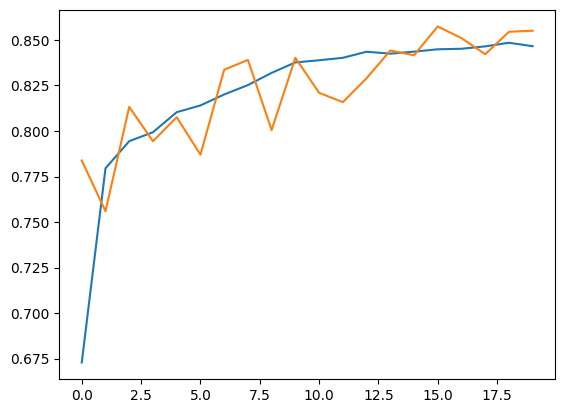

In [48]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

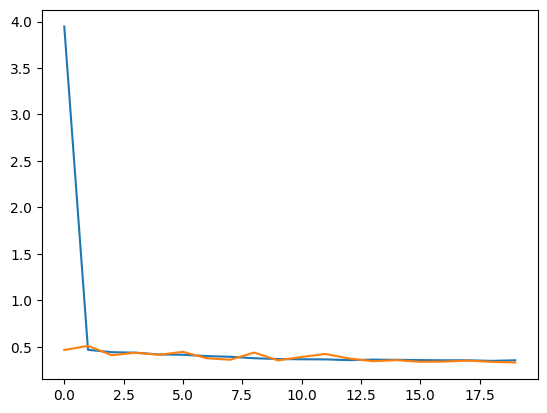

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Models I have Used are like below
  ReLU, Sigmoid, Tanh, Softmax, ELU Activations with Binary Crossentropy and Adam Optimizer.

In [50]:
# Model 2: ReLU activation, binary_crossentropy loss
model2 = Sequential()
model2.add(Dense(12, activation='relu', input_dim=12))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))
model2.summary()
model2.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
history2 = model2.fit(xtrain, ytrain, epochs=20, validation_split=0.2)

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 381 (1.49 KB)

 Trainable params: 381 (1.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7035 - loss: 0.6865 - val_accuracy: 0.7817 - val_loss: 0.4543
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7902 - loss: 0.4487 - val_accuracy: 0.8003 - val_loss: 0.4350
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8044 - loss: 0.4238 - val_accuracy: 0.8186 - val_loss: 0.4003
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8118 - loss: 0.4105 - val_accuracy: 0.8283 - val_loss: 0.3735
Epoch 5/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8271 - loss: 0.3751 - val_accuracy: 0.8440 - val_loss: 0.3509
Epoch 6/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8340 - loss: 0.3633 - val_accuracy: 0.8462 - val_loss: 0.3393
Epoch 7/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8383 - loss: 0.3535 - val_accuracy: 0.8495 - val_loss: 0.3321
Epoch 8/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8429 - loss: 0.3441 - 

In [51]:
# Model 3: Tanh activation, mean_squared_error loss
model3 = Sequential()
model3.add(Dense(12, activation='tanh', input_dim=12))
model3.add(Dense(12, activation='tanh'))
model3.add(Dense(1, activation='sigmoid'))
model3.summary()
model3.compile(loss='mean_squared_error', optimizer='Adam', metrics=['accuracy'])
history3 = model3.fit(xtrain, ytrain, epochs=20, validation_split=0.2)

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325 (1.27 KB)

 Trainable params: 325 (1.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6407 - loss: 0.2214 - val_accuracy: 0.7517 - val_loss: 0.1796
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7729 - loss: 0.1652 - val_accuracy: 0.7829 - val_loss: 0.1578
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7856 - loss: 0.1575 - val_accuracy: 0.7717 - val_loss: 0.1635
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7934 - loss: 0.1528 - val_accuracy: 0.7869 - val_loss: 0.1568
Epoch 5/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7985 - loss: 0.1499 - val_accuracy: 0.8035 - val_loss: 0.1470
Epoch 6/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8024 - loss: 0.1477 - val_accuracy: 0.8041 - val_loss: 0.1455
Epoch 7/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8034 - loss: 0.1463 - val_accuracy: 0.8101 - val_loss: 0.1435
Epoch 8/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8085 - loss: 0.1436 - 

In [52]:
# Model 4: Softmax activation, categorical_crossentropy loss
from tensorflow.keras.utils import to_categorical
ytrain_cat = to_categorical(ytrain)
ytest_cat = to_categorical(ytest)
model4 = Sequential()
model4.add(Dense(12, activation='relu', input_dim=12))
model4.add(Dense(12, activation='relu'))
model4.add(Dense(2, activation='softmax'))
model4.summary()
model4.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
history4 = model4.fit(xtrain, ytrain_cat, epochs=20, validation_split=0.2)

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338 (1.32 KB)

 Trainable params: 338 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7121 - loss: 1.4319 - val_accuracy: 0.6670 - val_loss: 0.6953
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7782 - loss: 0.4619 - val_accuracy: 0.7963 - val_loss: 0.4291
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7944 - loss: 0.4346 - val_accuracy: 0.8155 - val_loss: 0.4047
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8053 - loss: 0.4219 - val_accuracy: 0.7802 - val_loss: 0.4497
Epoch 5/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8125 - loss: 0.4070 - val_accuracy: 0.7880 - val_loss: 0.4351
Epoch 6/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8150 - loss: 0.4041 - val_accuracy: 0.8118 - val_loss: 0.3985
Epoch 7/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8169 - loss: 0.3997 - val_accuracy: 0.8047 - val_loss: 0.4127
Epoch 8/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8354 - loss: 0.3609 - 

In [53]:
# Model 5: ELU activation, hinge loss
model5 = Sequential()
model5.add(Dense(12, activation='elu', input_dim=12))
model5.add(Dense(6, activation='elu'))
model5.add(Dense(1, activation='sigmoid'))
model5.summary()
model5.compile(loss='hinge', optimizer='Adam', metrics=['accuracy'])
history5 = model5.fit(xtrain, ytrain, epochs=20, validation_split=0.2)

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 2/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 3/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 4/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 5/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 6/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 7/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4742 - loss: 1.0515 - val_accuracy: 0.4693 - val_loss: 1.0614
Epoch 8/20
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4742 - loss: 1.0515 - 